# Offline run analysis

Set `RUN_ID` to an existing online run folder for raw input data, and set `OFFLINE_RUN_ID` for this offline analysis pass. This notebook loads raw training and realtime trial `.npz` files from `runs/<RUN_ID>/`, applies its own preprocessing and audio-cue labeling settings, trains offline model variants, tests each on the realtime trial, and saves all notebook-03 outputs under `runs_offline/<OFFLINE_RUN_ID>/`. Models use time-domain EEG windows after this notebook's preprocessing step.


In [1]:
# imports 
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'training.py').exists():
    ROOT = Path(r'D:/BME/BCI/online_bci/online_eeg')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from preprocessing import (
    AudioLabelConfig,
    PreprocessConfig,
    labeled_preprocess_summary,
    preprocess_recording,
)
from training import (
    TrainingConfig,
    offline_train_test_sweep,
    rank_sweep_by_causal_delay,
    rank_sweep_summary,
    select_lowest_causal_delay_variant,
)
from testing import load_test_variant_artifacts
from plots import (
    plot_labeled_recording,
    plot_offline_variant_trace_and_xcov,
    plot_predictions_overlay,
    plot_xcov_curve,
)

print('Pipeline root:', ROOT)


Pipeline root: d:\BME\BCI\online_bci\online_eeg


## Raw files, preprocessing, and sweep settings


In [2]:
RUN_ID = 'run_001'
RUN_DIR = ROOT / 'runs' / RUN_ID

OFFLINE_RUN_ID = 'offline_001'  # Change this to keep a separate set of 03 outputs.
OFFLINE_ROOT = ROOT / 'runs_offline'
OFFLINE_RUN_DIR = OFFLINE_ROOT / OFFLINE_RUN_ID

TRAIN_RAW_NPZ = RUN_DIR / 'raw_training' / 'train_01.npz'
TEST_RAW_NPZ = RUN_DIR / 'realtime_trials' / 'realtime_trial_01_raw.npz'

EEG_CHANNELS = (1, 2, 3, 4)
EOG_CHANNELS = (5,)
EEG_CHANNEL_NAMES = ('O1', 'Oz', 'O2', 'POz')
AUDIO_CHANNEL = 16

APPLY_SOFTWARE_FILTERS = True  # BIOPAC hardware already bandpasses the EEG at 1-35 Hz.
DEMEAN_CHANNELS = True
SOFTWARE_BANDPASS_HZ = (8.0, 35.0)  # Set to (8.0, 35.0) to filter out blinks only if APPLY_SOFTWARE_FILTERS=True.
SOFTWARE_NOTCH_HZ = (60.0,)  # Set to (60.0,) only if APPLY_SOFTWARE_FILTERS=True.
PREPROCESS_TAG = 'software_filters_on' if APPLY_SOFTWARE_FILTERS else 'hardware_filter_only'
if DEMEAN_CHANNELS:
    PREPROCESS_TAG += '_demeaned'

OFFLINE_LABELED_DIR = OFFLINE_RUN_DIR / 'labeled'
TRAIN_LABELED_NPZ = OFFLINE_LABELED_DIR / f'{TRAIN_RAW_NPZ.stem}_labeled.npz'
TEST_LABELED_NPZ = OFFLINE_LABELED_DIR / f'{TEST_RAW_NPZ.stem}_labeled.npz'
SWEEP_DIR = OFFLINE_RUN_DIR / 'sweeps'

FEATURE_MODES = ('filtered_signal',)

WINDOW_SECS = (1.0, 2.0,)
# STRIDE_SECS = (0.05, 0.1, 0.2)
STRIDE_SECS = (0.02, 0.05, 0.1,)
LABEL_MODES = ('endpoint', 'majority')  # Include one or both: 'endpoint', 'majority'.

PRE = PreprocessConfig(
    eeg_channels=EEG_CHANNELS,
    eog_channels=EOG_CHANNELS,
    audio_channel=AUDIO_CHANNEL,
    apply_software_filters=APPLY_SOFTWARE_FILTERS,
    bandpass_low_hz=None if SOFTWARE_BANDPASS_HZ is None else SOFTWARE_BANDPASS_HZ[0],
    bandpass_high_hz=None if SOFTWARE_BANDPASS_HZ is None else SOFTWARE_BANDPASS_HZ[1],
    notch_hz=SOFTWARE_NOTCH_HZ,
    notch_quality_factor=30.0,
    filter_order=4,
    demean_channels=DEMEAN_CHANNELS,
)

LABELS = AudioLabelConfig(
    class_names=('Eyes Open', 'Eyes Closed'),
    baseline_label=0,
    active_label=1,
    cue_label_sequence=None,
    alternate_binary_labels=True,
    label_duration_sec=None,  # transition mode: each cue switches state until the next cue.
    label_start_offset_sec=0.0,  # label switch starts exactly at cue onset.
    envelope_window_sec=0.025,
    onset_threshold=None,
    onset_min_interval_sec=0.50,
)

TRAIN = TrainingConfig(
    train_fraction=1.0,
    # hidden_size=256,
    hidden_size=128,
    num_layers=2,
    dropout=0.2,
    batch_size=64,
    epochs=20,
    lr=1e-3,
    seed=888,
)

if not RUN_DIR.exists():
    raise FileNotFoundError(f'Run folder not found: {RUN_DIR}')
if not TRAIN_RAW_NPZ.exists():
    raise FileNotFoundError(f'Training raw file not found: {TRAIN_RAW_NPZ}')
if not TEST_RAW_NPZ.exists():
    raise FileNotFoundError(f'Test raw file not found: {TEST_RAW_NPZ}')

OFFLINE_LABELED_DIR.mkdir(parents=True, exist_ok=True)
SWEEP_DIR.mkdir(parents=True, exist_ok=True)
print('Run directory:', RUN_DIR)
print('Offline root:', OFFLINE_ROOT)
print('Offline run directory:', OFFLINE_RUN_DIR)
print('Training raw file:', TRAIN_RAW_NPZ)
print('Test raw file:', TEST_RAW_NPZ)
print('Offline labeled output:', OFFLINE_LABELED_DIR)
print('Sweep output:', SWEEP_DIR)
print('Preprocess tag:', PREPROCESS_TAG)
print('Software filters enabled:', APPLY_SOFTWARE_FILTERS)


Run directory: d:\BME\BCI\online_bci\online_eeg\runs\run_001
Offline root: d:\BME\BCI\online_bci\online_eeg\runs_offline
Offline run directory: d:\BME\BCI\online_bci\online_eeg\runs_offline\offline_001
Training raw file: d:\BME\BCI\online_bci\online_eeg\runs\run_001\raw_training\train_01.npz
Test raw file: d:\BME\BCI\online_bci\online_eeg\runs\run_001\realtime_trials\realtime_trial_01_raw.npz
Offline labeled output: d:\BME\BCI\online_bci\online_eeg\runs_offline\offline_001\labeled
Sweep output: d:\BME\BCI\online_bci\online_eeg\runs_offline\offline_001\sweeps
Preprocess tag: software_filters_on_demeaned
Software filters enabled: True


## Preprocess raw files for this offline analysis


In [3]:
TRAIN_LABELED_NPZ, train_cue_table = preprocess_recording(
    raw_npz=TRAIN_RAW_NPZ,
    output_npz=TRAIN_LABELED_NPZ,
    preprocess_config=PRE,
    label_config=LABELS,
)
TEST_LABELED_NPZ, test_cue_table = preprocess_recording(
    raw_npz=TEST_RAW_NPZ,
    output_npz=TEST_LABELED_NPZ,
    preprocess_config=PRE,
    label_config=LABELS,
)

preprocess_summary = labeled_preprocess_summary({
    'training': TRAIN_LABELED_NPZ,
    'realtime_test': TEST_LABELED_NPZ,
})
display(preprocess_summary)

print('Training cue table')
display(train_cue_table)
print('Realtime test cue table')
display(test_cue_table)


,name,path,samplerate,duration_sec,has_preprocess_config,has_apply_software_filters_flag,apply_software_filters,demean_channels,bandpass_low_hz,bandpass_high_hz,notch_hz,eeg_channels,audio_channel,source_raw_npz
0,training,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,200,300.0,True,True,True,True,8.0,35.0,[60.0],"[1, 2, 3, 4]",16,d:\BME\BCI\online_bci\online_eeg\runs\run_001\...
1,realtime_test,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,200,30.0,True,True,True,True,8.0,35.0,[60.0],"[1, 2, 3, 4]",16,d:\BME\BCI\online_bci\online_eeg\runs\run_001\...


Training cue table


,cue_index,onset_sample,onset_time_sec,label_start_sample,label_end_sample,label_start_time_sec,label_end_time_sec,label,label_name,peak_value
0,0,1155,5.775,1155,2163,5.775,10.815,1,Eyes Closed,1.030212
1,1,2163,10.815,2163,3135,10.815,15.675,0,Eyes Open,1.040991
2,2,3135,15.675,3135,4183,15.675,20.915,1,Eyes Closed,1.046932
3,3,4183,20.915,4183,5851,20.915,29.255,0,Eyes Open,1.041953
4,4,5851,29.255,5851,7508,29.255,37.540,1,Eyes Closed,1.047938
5,5,7508,37.540,7508,8295,37.540,41.475,0,Eyes Open,1.047303
6,6,8295,41.475,8295,9107,41.475,45.535,1,Eyes Closed,1.044649
7,7,9107,45.535,9107,11099,45.535,55.495,0,Eyes Open,1.044290
8,8,11099,55.495,11099,13139,55.495,65.695,1,Eyes Closed,1.039200
9,9,13139,65.695,13139,13711,65.695,68.555,0,Eyes Open,1.049705


Realtime test cue table


,cue_index,onset_sample,onset_time_sec,label_start_sample,label_end_sample,label_start_time_sec,label_end_time_sec,label,label_name,peak_value
0,0,1715,8.575,1715,3331,8.575,16.655,1,Eyes Closed,1.038022
1,1,3331,16.655,3331,5030,16.655,25.150,0,Eyes Open,1.035590
2,2,5030,25.150,5030,6000,25.150,30.000,1,Eyes Closed,1.040509


## Inspect freshly labeled train/test data


Text(0.5, 1.0, 'Training labeled EEG preview')

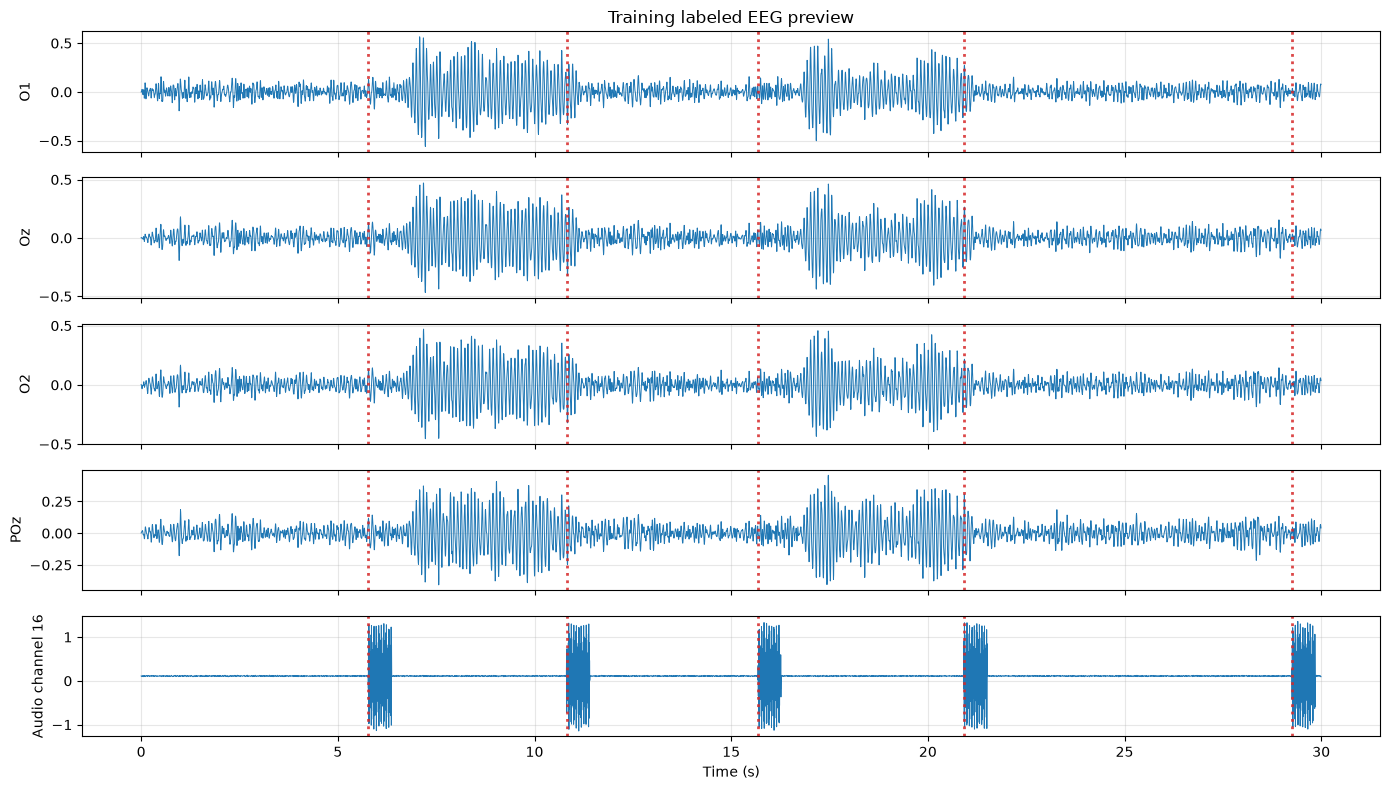

In [4]:
fig, axes = plot_labeled_recording(
    TRAIN_LABELED_NPZ,
    max_duration_sec=30.0,
    channel_names=EEG_CHANNEL_NAMES,
)
axes[0].set_title('Training labeled EEG preview')


Text(0.5, 1.0, 'Realtime trial labeled EEG preview')

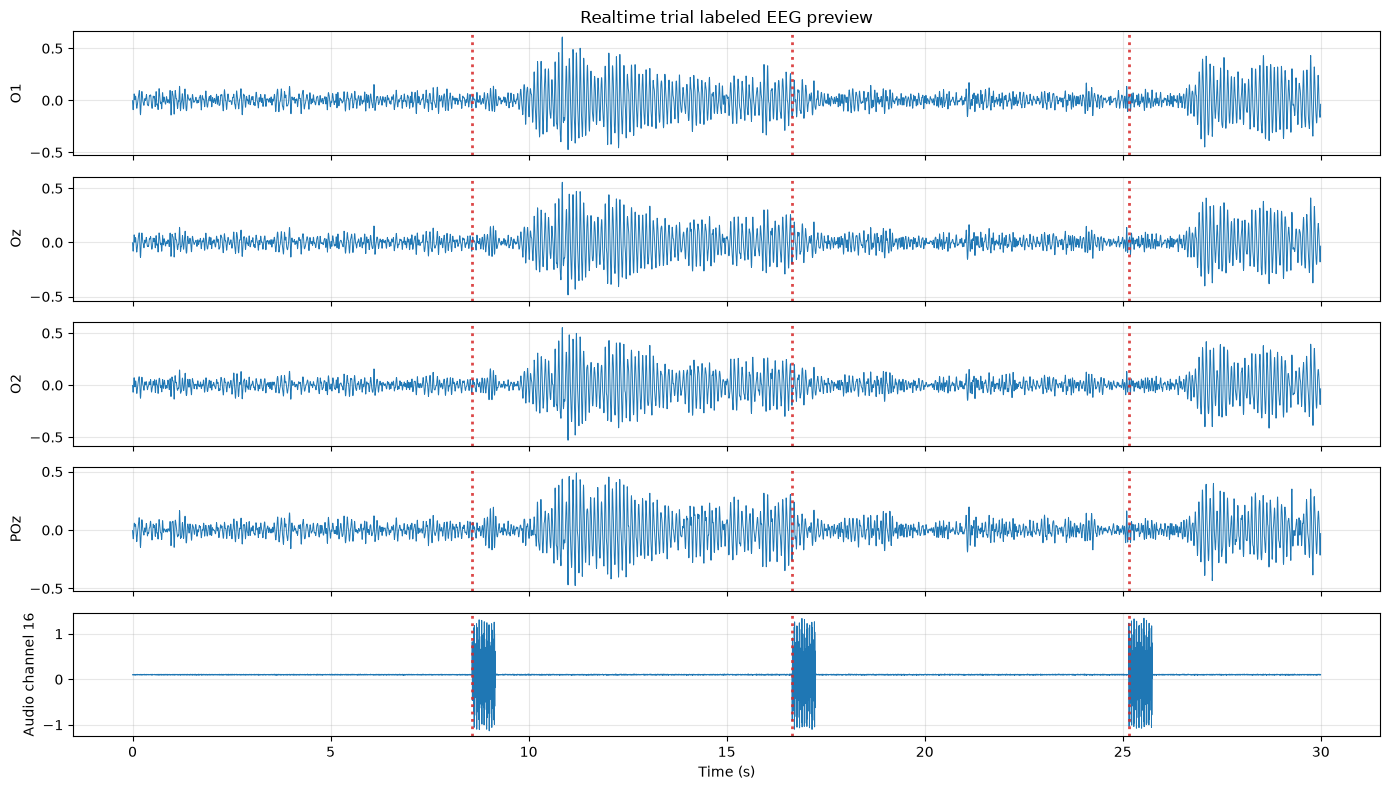

In [5]:
fig, axes = plot_labeled_recording(
    TEST_LABELED_NPZ,
    max_duration_sec=None,
    channel_names=EEG_CHANNEL_NAMES,
)
axes[0].set_title('Realtime trial labeled EEG preview')


## Run offline model sweep


In [6]:
sweep_result = offline_train_test_sweep(
    train_labeled_npz=TRAIN_LABELED_NPZ,
    test_labeled_npz=TEST_LABELED_NPZ,
    output_dir=SWEEP_DIR,
    feature_modes=FEATURE_MODES,
    window_secs=WINDOW_SECS,
    stride_secs=STRIDE_SECS,
    training_config=TRAIN,
    label_modes=LABEL_MODES,
)

RANK_COLUMN = 'test_xcov_peak_coeff'
summary = rank_sweep_summary(sweep_result['summary'], rank_column=RANK_COLUMN)
print('Saved sweep summary:', sweep_result['summary_csv'])
print(f'Ranked variants by {RANK_COLUMN} descending; balanced accuracy is used only as a tie-breaker.')
display(summary)


Saved sweep summary: d:\BME\BCI\online_bci\online_eeg\runs_offline\offline_001\sweeps\offline_sweep_summary.csv
Ranked variants by test_xcov_peak_coeff descending; balanced accuracy is used only as a tie-breaker.


,variant,feature_mode,label_mode,window_sec,stride_sec,checkpoint_path,variant_dir,validation_aligned_prediction_csv,test_aligned_prediction_csv,val_accuracy,...,test_n_windows,test_mean_cue_to_first_correct_sec,test_median_cue_to_first_correct_sec,test_mean_cue_to_predicted_transition_sec,test_median_cue_to_predicted_transition_sec,test_mean_cue_to_sustained_prediction_sec,test_median_cue_to_sustained_prediction_sec,test_xcov_delay_sec,test_xcov_peak_coeff,test_xcov_signal_column
0,filtered_signal__win_2p0s__stride_0p05s__label...,filtered_signal,majority,2.0,0.05,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,1.0,...,561.0,1.890000,1.850,1.890000,1.850,1.890000,1.850,1.850,0.965137,prob_Eyes Closed
1,filtered_signal__win_1p0s__stride_0p05s__label...,filtered_signal,majority,1.0,0.05,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,1.0,...,581.0,1.490000,1.375,1.490000,1.375,1.573333,1.625,1.625,0.943732,prob_Eyes Closed
2,filtered_signal__win_1p0s__stride_0p02s__label...,filtered_signal,majority,1.0,0.02,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,1.0,...,1451.0,1.293333,1.625,1.293333,1.625,1.353333,1.625,1.585,0.925903,prob_Eyes Closed
3,filtered_signal__win_2p0s__stride_0p05s__label...,filtered_signal,endpoint,2.0,0.05,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,1.0,...,561.0,1.006667,0.945,1.006667,0.945,1.040000,0.945,1.375,0.912464,prob_Eyes Closed
4,filtered_signal__win_1p0s__stride_0p02s__label...,filtered_signal,endpoint,1.0,0.02,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,1.0,...,1451.0,0.833333,0.485,0.833333,0.485,0.833333,0.485,1.345,0.902264,prob_Eyes Closed
5,filtered_signal__win_2p0s__stride_0p1s__labels...,filtered_signal,majority,2.0,0.10,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,1.0,...,281.0,0.940000,0.545,0.940000,0.545,1.373333,1.625,1.425,0.898841,prob_Eyes Closed
6,filtered_signal__win_2p0s__stride_0p02s__label...,filtered_signal,endpoint,2.0,0.02,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,1.0,...,1401.0,0.880000,0.485,0.880000,0.485,0.880000,0.485,1.365,0.897196,prob_Eyes Closed
7,filtered_signal__win_2p0s__stride_0p1s__labels...,filtered_signal,endpoint,2.0,0.10,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,1.0,...,281.0,0.873333,0.545,0.873333,0.545,1.240000,1.425,1.425,0.893728,prob_Eyes Closed
8,filtered_signal__win_2p0s__stride_0p02s__label...,filtered_signal,majority,2.0,0.02,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,1.0,...,1401.0,0.420000,0.025,0.420000,0.025,1.746667,1.765,1.765,0.892743,prob_Eyes Closed
9,filtered_signal__win_1p0s__stride_0p05s__label...,filtered_signal,endpoint,1.0,0.05,d:\BME\BCI\online_bci\online_ee

## Compare variants


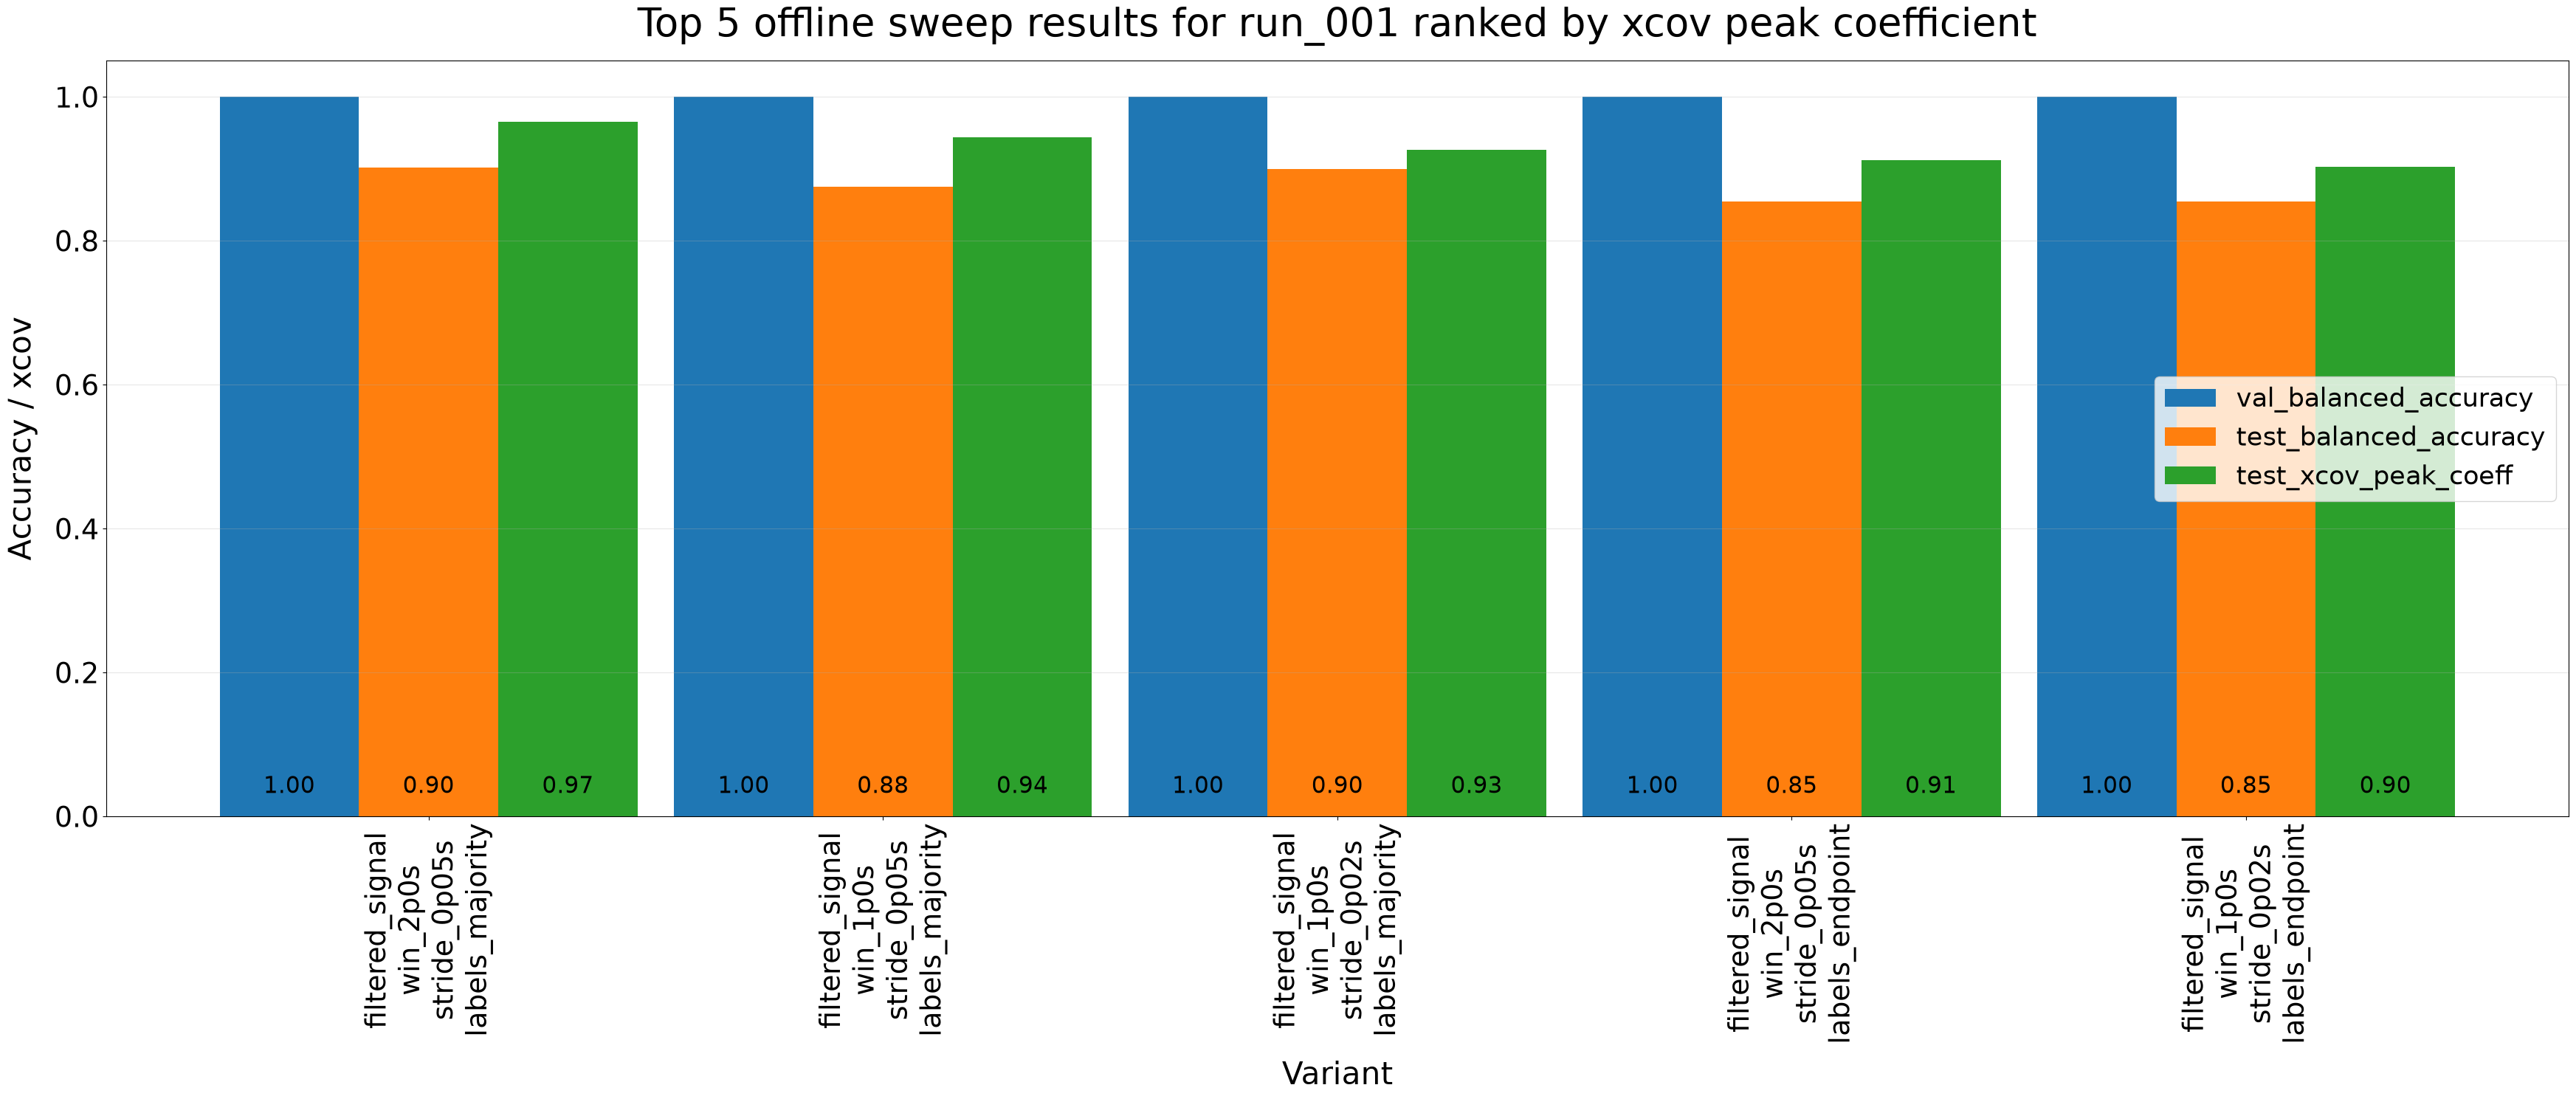

In [7]:
TOP_N_VARIANTS = 5
plot_df = summary.head(TOP_N_VARIANTS).copy()
plot_df['variant_short'] = plot_df['variant'].str.replace('__', '\n', regex=False)
plot_df['test_xcov_peak_coeff'] = pd.to_numeric(plot_df['test_xcov_peak_coeff'], errors='coerce')
ax = plot_df.plot.bar(
    x='variant_short',
    y=['val_balanced_accuracy', 'test_balanced_accuracy', 'test_xcov_peak_coeff'],
    figsize=(35, 15),
    width=0.92,
)
ax.set_xlabel('Variant', fontsize=30, labelpad=16)
ax.set_ylabel('Accuracy / xcov', fontsize=30, labelpad=16)
ax.set_ylim(0.0, 1.05)
ax.set_title(
    f'Top {TOP_N_VARIANTS} offline sweep results for {RUN_ID} ranked by xcov peak coefficient',
    fontsize=38,
    pad=24,
)
ax.tick_params(axis='x', labelsize=27, rotation=90)
ax.tick_params(axis='y', labelsize=27)
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if pd.notna(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2.0,
                0.025,
                f'{float(height):.2f}',
                ha='center',
                va='bottom',
                fontsize=22,
                color='black',
                clip_on=True,
            )
ax.legend(fontsize=25, loc='center right')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()


## Inspect best variant predictions


Best variant by xcov peak coefficient: filtered_signal__win_2p0s__stride_0p05s__labels_majority
Best xcov peak coefficient: 0.9651373941205141
Best xcov delay sec: 1.85
Best predictions: d:\BME\BCI\online_bci\online_eeg\runs_offline\offline_001\sweeps\filtered_signal__win_2p0s__stride_0p05s__labels_majority\realtime_trial_01_raw_labeled_test_predictions.csv
Best aligned EEG/predictions: d:\BME\BCI\online_bci\online_eeg\runs_offline\offline_001\sweeps\filtered_signal__win_2p0s__stride_0p05s__labels_majority\realtime_trial_01_raw_labeled_test_predictions_aligned_eeg.csv


,start_sample,end_sample,start_time_sec,end_time_sec,label,true_label,pred_label,correct,prob_Eyes Open,prob_Eyes Closed
556,5560,5960,27.80,29.80,1,1,1,True,0.018857,0.981143
557,5570,5970,27.85,29.85,1,1,1,True,0.040565,0.959435
558,5580,5980,27.90,29.90,1,1,1,True,0.015648,0.984352
559,5590,5990,27.95,29.95,1,1,1,True,0.032306,0.967694
560,5600,6000,28.00,30.00,1,1,1,True,0.014994,0.985006


,n_cues,n_matched_first_correct,mean_cue_to_first_correct_sec,median_cue_to_first_correct_sec,n_matched_predicted_transition,mean_cue_to_predicted_transition_sec,median_cue_to_predicted_transition_sec,n_matched_sustained,mean_cue_to_sustained_prediction_sec,median_cue_to_sustained_prediction_sec
0,3,3,1.89,1.85,3,1.89,1.85,3,1.89,1.85


,target_label,target_label_name,prediction_signal_column,xcov_delay_sec,xcov_lag_samples,xcov_peak_coeff,max_lag_sec,n_valid_samples
0,1,Eyes Closed,prob_Eyes Closed,1.85,370,0.965137,10.0,5600


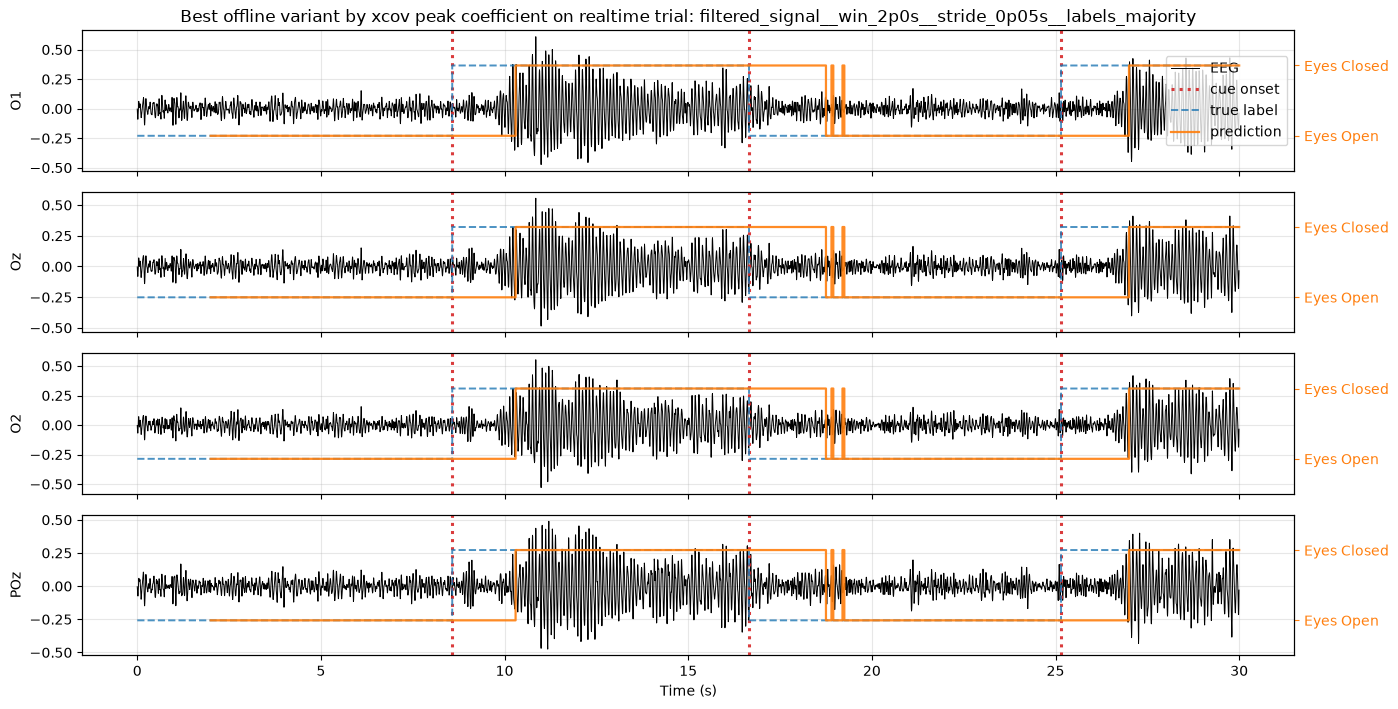

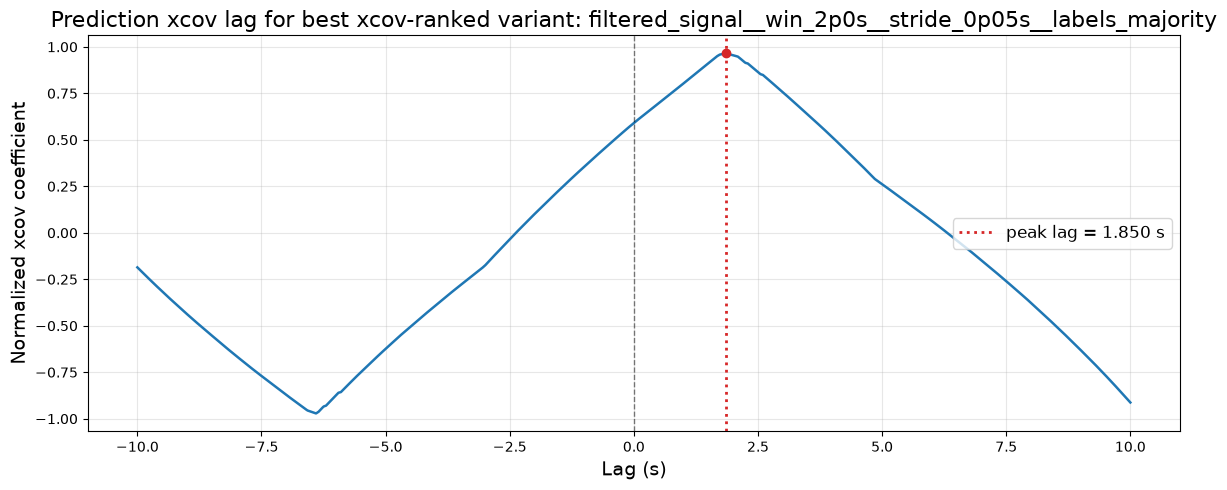

In [8]:
best = summary.iloc[0]
best_artifacts = load_test_variant_artifacts(best, TEST_LABELED_NPZ)
best_paths = best_artifacts['paths']
best_predictions = best_artifacts['predictions']
best_cue_delay_summary = best_artifacts['cue_delay_summary']
best_xcov_delay_summary = best_artifacts['xcov_delay_summary']
best_xcov_curve = best_artifacts['xcov_curve']

print('Best variant by xcov peak coefficient:', best['variant'])
print('Best xcov peak coefficient:', best.get('test_xcov_peak_coeff'))
print('Best xcov delay sec:', best.get('test_xcov_delay_sec'))
print('Best predictions:', best_paths['prediction_csv'])
print('Best aligned EEG/predictions:', best_paths['aligned_prediction_csv'])

display(best_predictions.tail())
if best_cue_delay_summary is not None:
    display(best_cue_delay_summary)
if best_xcov_delay_summary is not None:
    display(best_xcov_delay_summary)

fig, axes = plot_predictions_overlay(
    TEST_LABELED_NPZ,
    best_predictions,
    max_duration_sec=None,
    channel_names=EEG_CHANNEL_NAMES,
    show_true_labels=True,
    legend_loc='center right',
)
axes[0].set_title(f"Best offline variant by xcov peak coefficient on realtime trial: {best['variant']}")

if best_xcov_curve is not None and best_xcov_delay_summary is not None:
    fig, ax = plot_xcov_curve(
        best_xcov_curve,
        best_xcov_delay_summary,
        title=f"Prediction xcov lag for best xcov-ranked variant: {best['variant']}",
    )


## Compare variants by causal delay

The xcov lag is signed: positive delay means the prediction trace lags the label trace, while negative delay means the prediction trace leads the label trace. For a causal real-time model, negative delay should not be rewarded in the main delay ranking. This plot ranks variants with nonnegative xcov delay first, because those represent predictions that follow the label transition. Negative-delay variants remain in the full summary table but are placed after all nonnegative-delay variants here.


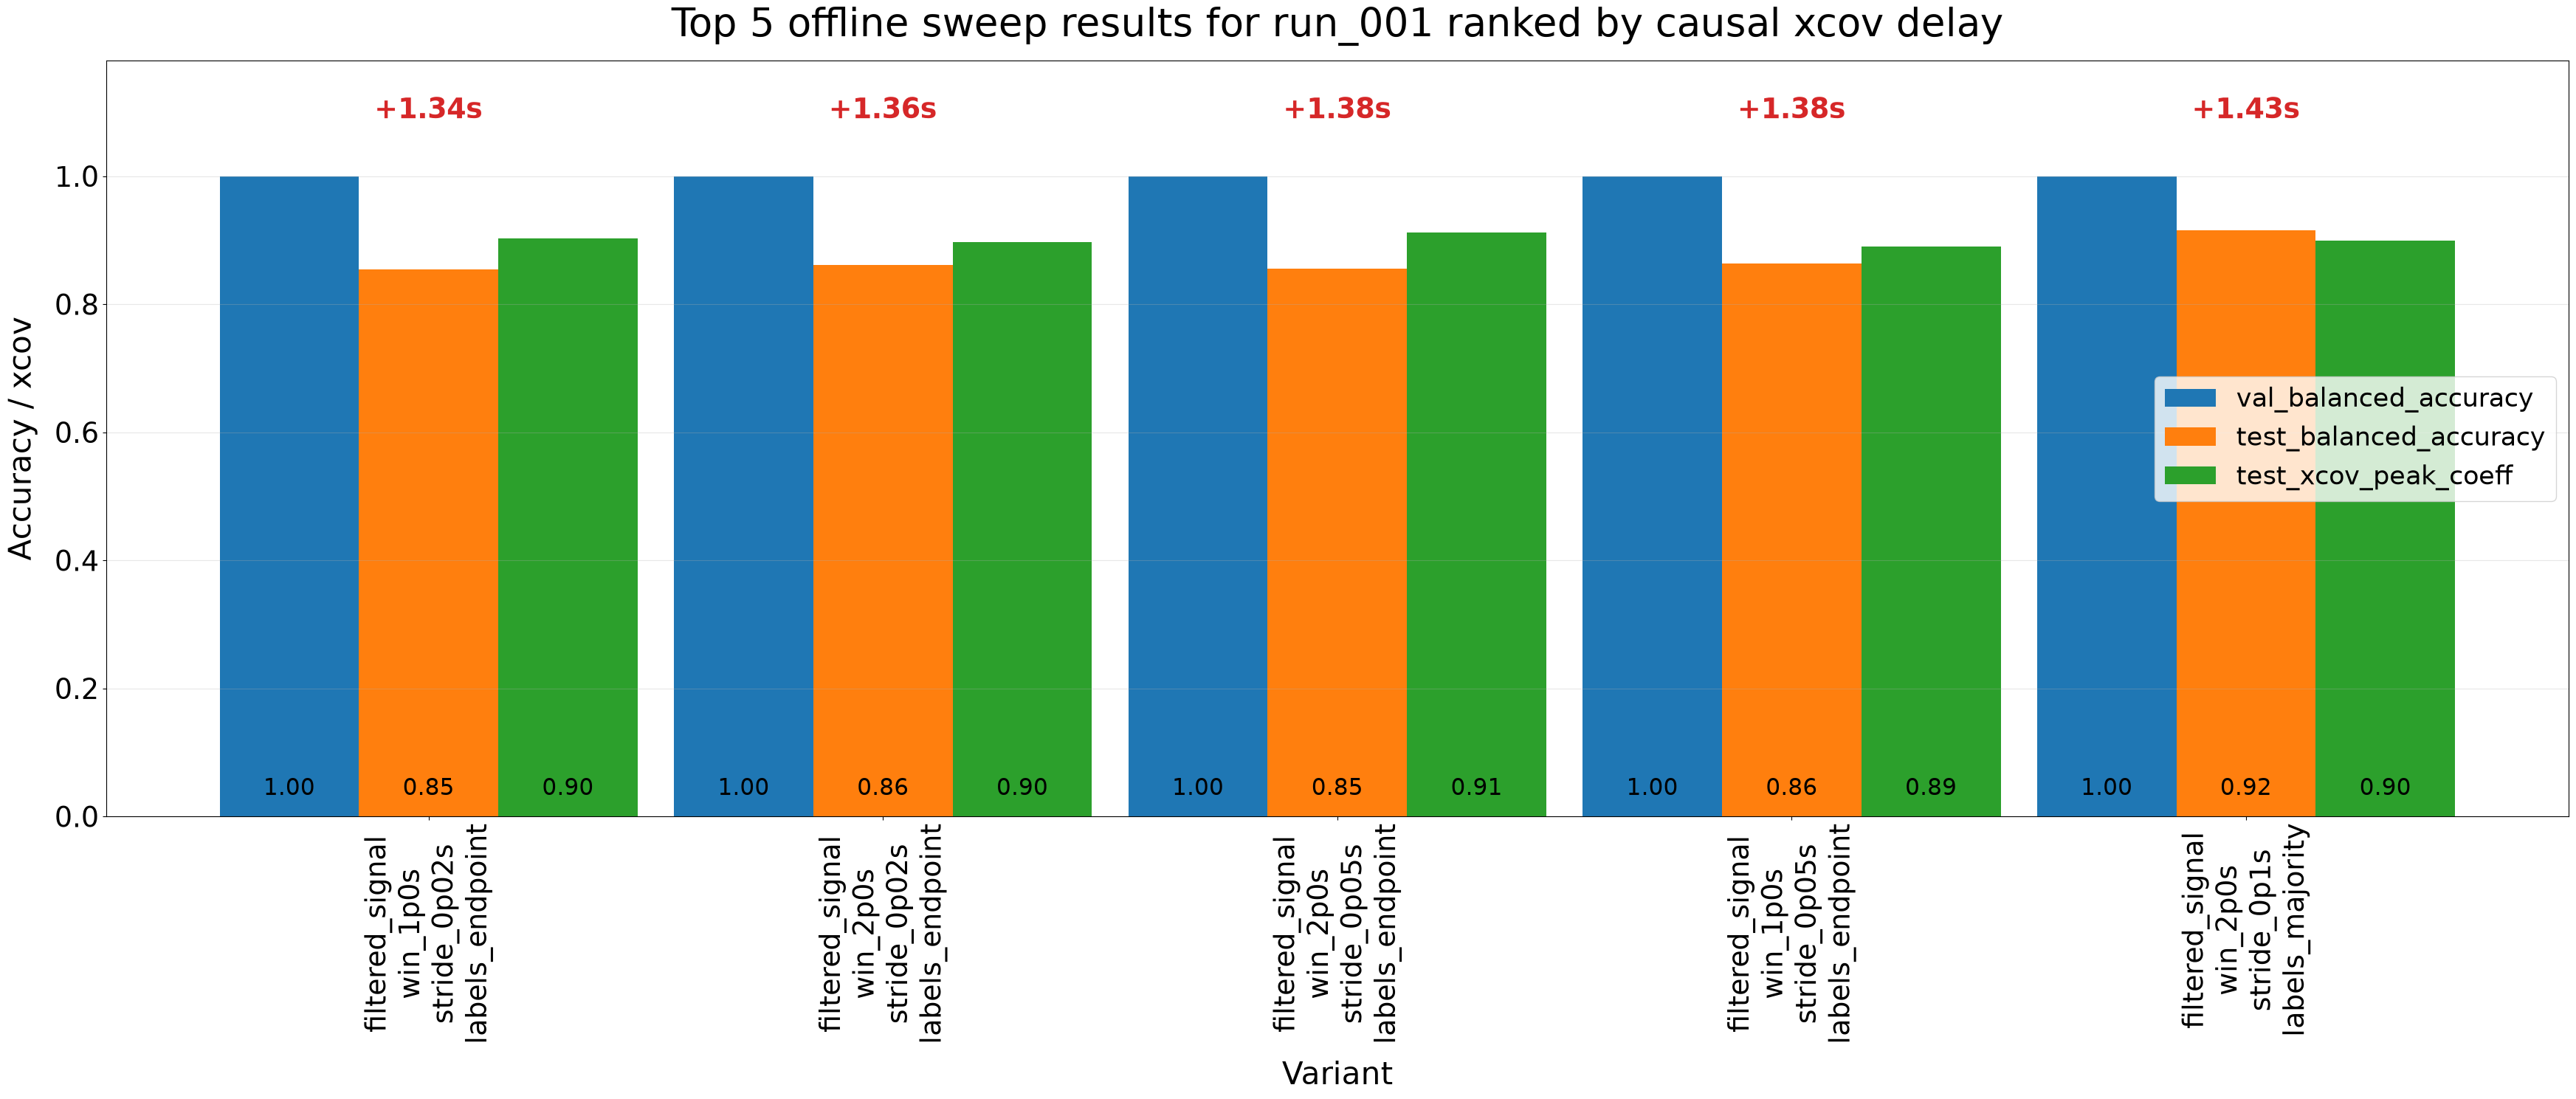

In [9]:
DELAY_TOP_N_VARIANTS = 5
delay_plot_df = rank_sweep_by_causal_delay(summary).head(DELAY_TOP_N_VARIANTS).copy()
delay_plot_df['variant_short'] = delay_plot_df['variant'].str.replace('__', '\n', regex=False)

ax = delay_plot_df.plot.bar(
    x='variant_short',
    y=['val_balanced_accuracy', 'test_balanced_accuracy', 'test_xcov_peak_coeff'],
    figsize=(35, 15),
    width=0.92,
)
ax.set_xlabel('Variant', fontsize=30, labelpad=16)
ax.set_ylabel('Accuracy / xcov', fontsize=30, labelpad=16)
ax.set_ylim(0.0, 1.18)
ax.set_title(
    f'Top {DELAY_TOP_N_VARIANTS} offline sweep results for {RUN_ID} ranked by causal xcov delay',
    fontsize=38,
    pad=24,
)
ax.tick_params(axis='x', labelsize=27, rotation=90)
ax.tick_params(axis='y', labelsize=27)
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if pd.notna(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2.0,
                0.025,
                f'{float(height):.2f}',
                ha='center',
                va='bottom',
                fontsize=22,
                color='black',
                clip_on=True,
            )
ax.legend(fontsize=25, loc='center right')
ax.grid(True, axis='y', alpha=0.3)

for idx, value in enumerate(delay_plot_df['test_xcov_delay_sec']):
    if pd.notna(value):
        ax.text(
            idx,
            1.08,
            f'{float(value):+.2f}s',
            ha='center',
            va='bottom',
            fontsize=27,
            color='tab:red',
            fontweight='bold',
        )
plt.tight_layout()


## Inspect lowest causal-delay variant predictions

This repeats the same diagnostic printouts and plots for the fastest valid causal-delay combination. Negative xcov delays are excluded from this selection because a negative delay means the prediction trace leads the true label trace, which should not be treated as real-time prediction latency.


Lowest causal-delay variant: filtered_signal__win_1p0s__stride_0p02s__labels_endpoint
Lowest causal xcov delay sec: 1.345
Lowest causal-delay xcov peak coefficient: 0.9022639890053649
Lowest causal-delay predictions: d:\BME\BCI\online_bci\online_eeg\runs_offline\offline_001\sweeps\filtered_signal__win_1p0s__stride_0p02s__labels_endpoint\realtime_trial_01_raw_labeled_test_predictions.csv
Lowest causal-delay aligned EEG/predictions: d:\BME\BCI\online_bci\online_eeg\runs_offline\offline_001\sweeps\filtered_signal__win_1p0s__stride_0p02s__labels_endpoint\realtime_trial_01_raw_labeled_test_predictions_aligned_eeg.csv


,start_sample,end_sample,start_time_sec,end_time_sec,label,true_label,pred_label,correct,prob_Eyes Open,prob_Eyes Closed
1446,5784,5984,28.92,29.92,1,1,1,True,0.064721,0.935279
1447,5788,5988,28.94,29.94,1,1,1,True,0.102201,0.897799
1448,5792,5992,28.96,29.96,1,1,1,True,0.079132,0.920868
1449,5796,5996,28.98,29.98,1,1,1,True,0.125440,0.874560
1450,5800,6000,29.00,30.00,1,1,1,True,0.085454,0.914547


,n_cues,n_matched_first_correct,mean_cue_to_first_correct_sec,median_cue_to_first_correct_sec,n_matched_predicted_transition,mean_cue_to_predicted_transition_sec,median_cue_to_predicted_transition_sec,n_matched_sustained,mean_cue_to_sustained_prediction_sec,median_cue_to_sustained_prediction_sec
0,3,3,0.833333,0.485,3,0.833333,0.485,3,0.833333,0.485


,target_label,target_label_name,prediction_signal_column,xcov_delay_sec,xcov_lag_samples,xcov_peak_coeff,max_lag_sec,n_valid_samples
0,1,Eyes Closed,prob_Eyes Closed,1.345,269,0.902264,10.0,5800


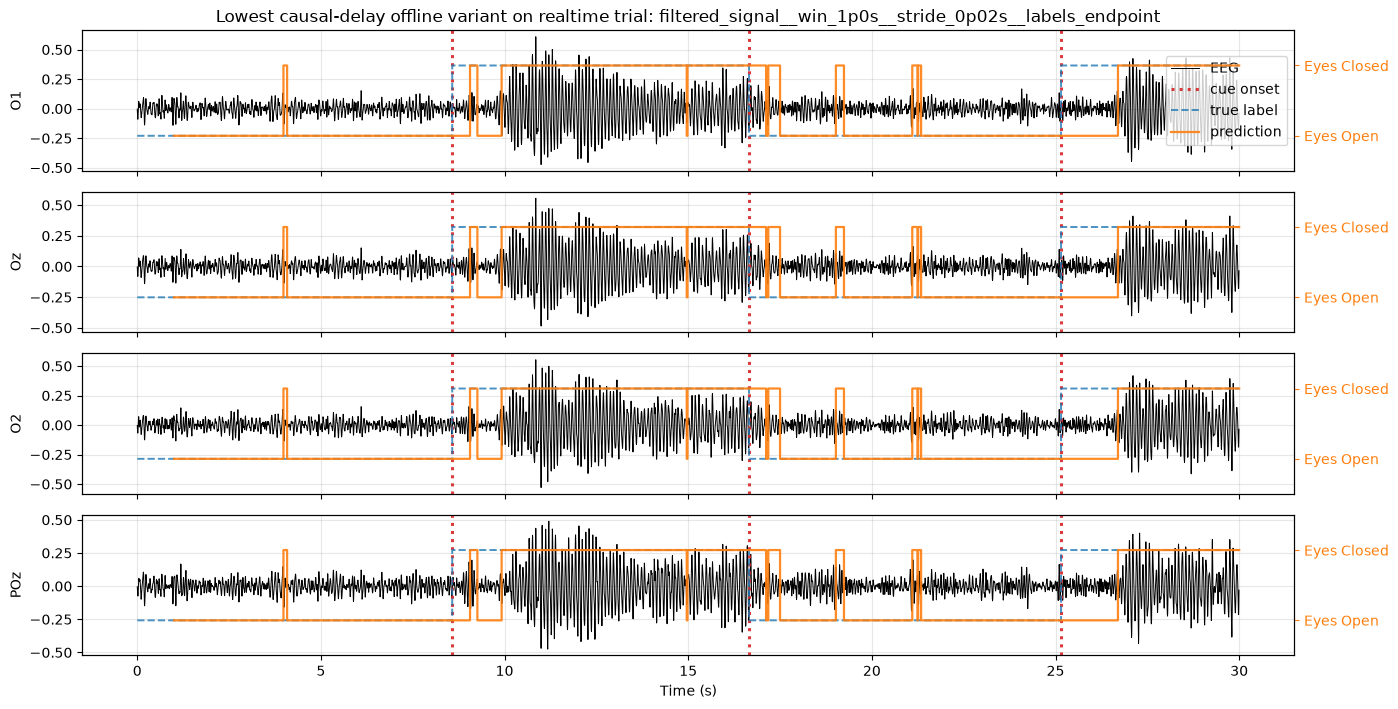

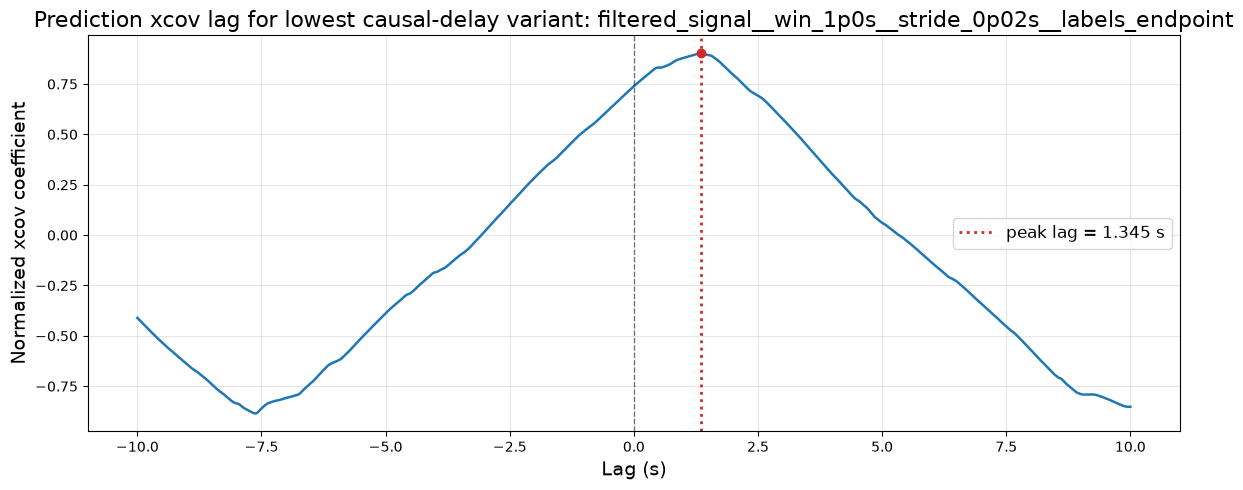

In [10]:
lowest_delay = select_lowest_causal_delay_variant(summary)
lowest_delay_artifacts = load_test_variant_artifacts(lowest_delay, TEST_LABELED_NPZ)
lowest_delay_paths = lowest_delay_artifacts['paths']
lowest_delay_predictions = lowest_delay_artifacts['predictions']
lowest_delay_cue_delay_summary = lowest_delay_artifacts['cue_delay_summary']
lowest_delay_xcov_delay_summary = lowest_delay_artifacts['xcov_delay_summary']
lowest_delay_xcov_curve = lowest_delay_artifacts['xcov_curve']

print('Lowest causal-delay variant:', lowest_delay['variant'])
print('Lowest causal xcov delay sec:', lowest_delay.get('test_xcov_delay_sec'))
print('Lowest causal-delay xcov peak coefficient:', lowest_delay.get('test_xcov_peak_coeff'))
print('Lowest causal-delay predictions:', lowest_delay_paths['prediction_csv'])
print('Lowest causal-delay aligned EEG/predictions:', lowest_delay_paths['aligned_prediction_csv'])

display(lowest_delay_predictions.tail())
if lowest_delay_cue_delay_summary is not None:
    display(lowest_delay_cue_delay_summary)
if lowest_delay_xcov_delay_summary is not None:
    display(lowest_delay_xcov_delay_summary)

fig, axes = plot_predictions_overlay(
    TEST_LABELED_NPZ,
    lowest_delay_predictions,
    max_duration_sec=None,
    channel_names=EEG_CHANNEL_NAMES,
    show_true_labels=True,
    legend_loc='center right',
)
axes[0].set_title(
    f"Lowest causal-delay offline variant on realtime trial: {lowest_delay['variant']}"
)

if lowest_delay_xcov_curve is not None and lowest_delay_xcov_delay_summary is not None:
    fig, ax = plot_xcov_curve(
        lowest_delay_xcov_curve,
        lowest_delay_xcov_delay_summary,
        title=f"Prediction xcov lag for lowest causal-delay variant: {lowest_delay['variant']}",
    )


## Inspect any variant by window, stride, and label mode

Set the window, stride, and label mode below to pull that exact sweep result. This is useful for comparing the xcov-ranked or delay-ranked winners against another variant while keeping the same trace plot, xcov plot, and summary tables.


Selected comparison variant: filtered_signal__win_2p0s__stride_0p05s__labels_majority
Selected comparison xcov delay sec: 1.85
Selected comparison xcov peak coefficient: 0.9651373941205141
Selected comparison predictions: d:\BME\BCI\online_bci\online_eeg\runs_offline\offline_001\sweeps\filtered_signal__win_2p0s__stride_0p05s__labels_majority\realtime_trial_01_raw_labeled_test_predictions.csv
Selected comparison aligned EEG/predictions: d:\BME\BCI\online_bci\online_eeg\runs_offline\offline_001\sweeps\filtered_signal__win_2p0s__stride_0p05s__labels_majority\realtime_trial_01_raw_labeled_test_predictions_aligned_eeg.csv


,start_sample,end_sample,start_time_sec,end_time_sec,label,true_label,pred_label,correct,prob_Eyes Open,prob_Eyes Closed
556,5560,5960,27.80,29.80,1,1,1,True,0.018857,0.981143
557,5570,5970,27.85,29.85,1,1,1,True,0.040565,0.959435
558,5580,5980,27.90,29.90,1,1,1,True,0.015648,0.984352
559,5590,5990,27.95,29.95,1,1,1,True,0.032306,0.967694
560,5600,6000,28.00,30.00,1,1,1,True,0.014994,0.985006


,n_cues,n_matched_first_correct,mean_cue_to_first_correct_sec,median_cue_to_first_correct_sec,n_matched_predicted_transition,mean_cue_to_predicted_transition_sec,median_cue_to_predicted_transition_sec,n_matched_sustained,mean_cue_to_sustained_prediction_sec,median_cue_to_sustained_prediction_sec
0,3,3,1.89,1.85,3,1.89,1.85,3,1.89,1.85


,target_label,target_label_name,prediction_signal_column,xcov_delay_sec,xcov_lag_samples,xcov_peak_coeff,max_lag_sec,n_valid_samples
0,1,Eyes Closed,prob_Eyes Closed,1.85,370,0.965137,10.0,5600


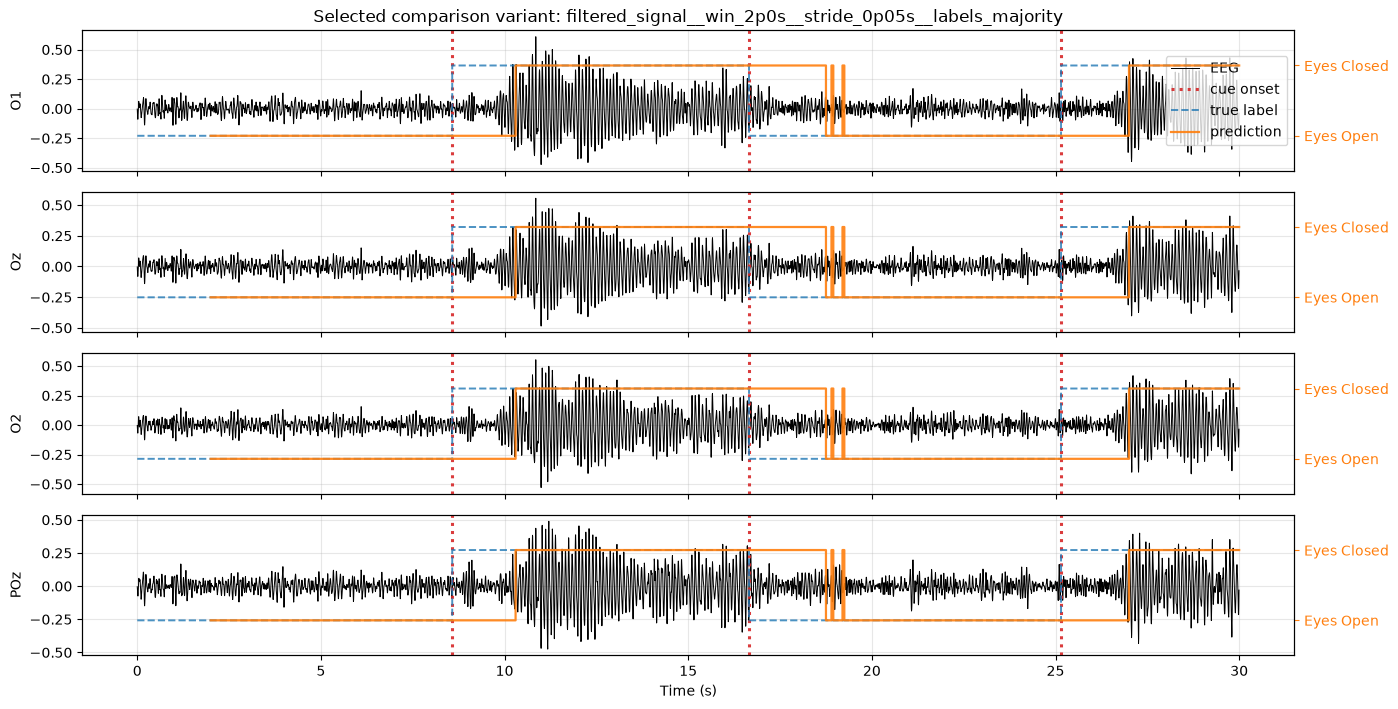

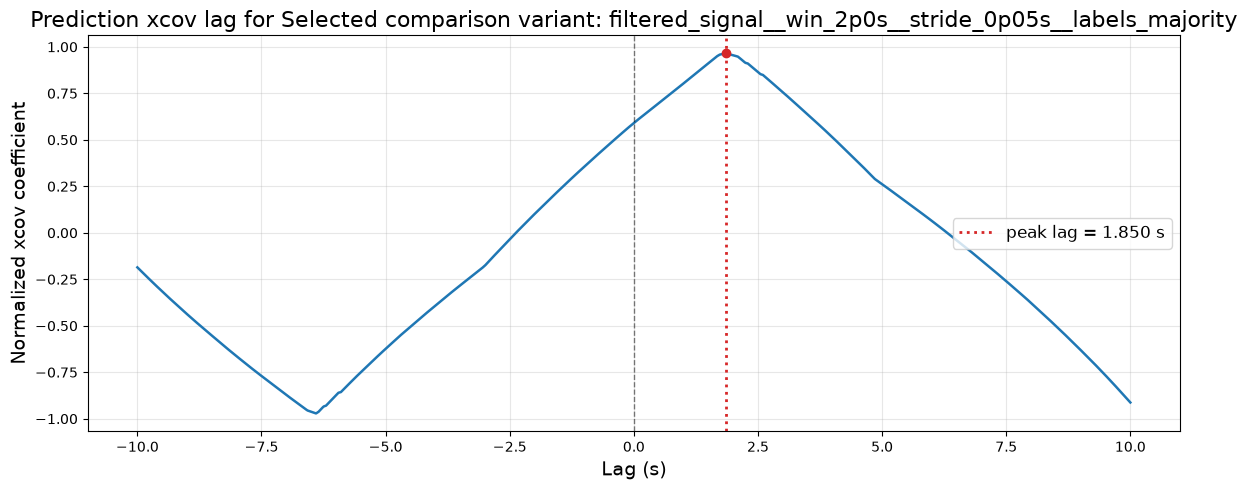

In [11]:
COMPARE_FEATURE_MODE = 'filtered_signal'
COMPARE_WINDOW_SEC = 2.0
COMPARE_STRIDE_SEC = 0.05
COMPARE_LABEL_MODE = 'majority'  # 'endpoint' or 'majority'

compare_result = plot_offline_variant_trace_and_xcov(
    summary=summary,
    labeled_npz=TEST_LABELED_NPZ,
    feature_mode=COMPARE_FEATURE_MODE,
    window_sec=COMPARE_WINDOW_SEC,
    stride_sec=COMPARE_STRIDE_SEC,
    label_mode=COMPARE_LABEL_MODE,
    channel_names=EEG_CHANNEL_NAMES,
    max_duration_sec=None,
    show_true_labels=True,
    legend_loc='center right',
    title_prefix='Selected comparison variant',
)
compare_row = compare_result['row']
compare_artifacts = compare_result['artifacts']
compare_paths = compare_artifacts['paths']

print('Selected comparison variant:', compare_row['variant'])
print('Selected comparison xcov delay sec:', compare_row.get('test_xcov_delay_sec'))
print('Selected comparison xcov peak coefficient:', compare_row.get('test_xcov_peak_coeff'))
print('Selected comparison predictions:', compare_paths['prediction_csv'])
print('Selected comparison aligned EEG/predictions:', compare_paths['aligned_prediction_csv'])

display(compare_artifacts['predictions'].tail())
if compare_artifacts['cue_delay_summary'] is not None:
    display(compare_artifacts['cue_delay_summary'])
if compare_artifacts['xcov_delay_summary'] is not None:
    display(compare_artifacts['xcov_delay_summary'])
